In [3]:
import os

os.makedirs("dataset/normal", exist_ok=True)

In [4]:
import shutil
import os

for file in os.listdir():
    if file.endswith(('.jpg', '.jpeg', '.png')):
        shutil.move(file, f"dataset/normal/{file}")

In [5]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')
remaining_image_files = [f for f in os.listdir('.') if f.lower().endswith(image_extensions)]

if remaining_image_files:
    print(f"The following image files are still in the current directory: {remaining_image_files}")
else:
    print("No image files (jpg, jpeg, png, gif, bmp, tiff, webp) were found in the current directory.")

No image files (jpg, jpeg, png, gif, bmp, tiff, webp) were found in the current directory.


In [7]:
import os
os.makedirs("dataset/eczema", exist_ok=True)

In [8]:
import shutil
import os

for file in os.listdir():
    if file.endswith(('.jpg', '.jpeg', '.png')):
        shutil.move(file, f"dataset/eczema/{file}")

In [9]:
print("Eczema:", len(os.listdir("dataset/eczema")))
print("Normal:", len(os.listdir("dataset/normal")))

Eczema: 1544
Normal: 315


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train = datagen.flow_from_directory(
    "dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val = datagen.flow_from_directory(
    "dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 1488 images belonging to 2 classes.
Found 371 images belonging to 2 classes.


In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
history = model.fit(
    train,
    validation_data=val,
    epochs=8
)

Epoch 1/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 981ms/step - accuracy: 0.7977 - loss: 0.5789 - val_accuracy: 0.8329 - val_loss: 0.2775
Epoch 2/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8851 - loss: 0.2571 - val_accuracy: 0.8787 - val_loss: 0.2447
Epoch 3/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 939ms/step - accuracy: 0.9355 - loss: 0.1774 - val_accuracy: 0.9164 - val_loss: 0.2002
Epoch 4/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 978ms/step - accuracy: 0.9415 - loss: 0.1501 - val_accuracy: 0.9515 - val_loss: 0.1374
Epoch 5/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 954ms/step - accuracy: 0.9496 - loss: 0.1534 - val_accuracy: 0.9461 - val_loss: 0.1375
Epoch 6/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 932ms/step - accuracy: 0.9543 - loss: 0.1210 - val_accuracy: 0.9488 - val_loss: 0.1274
Epoch 7/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 964ms/step - accuracy: 0.9563 - loss: 0.1177 - val_accuracy: 0.9596 - val_loss: 0.0943
Epoch 8/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 924ms/step - accuracy: 0.9597 - loss: 0.1199 - val_accuracy: 0.965

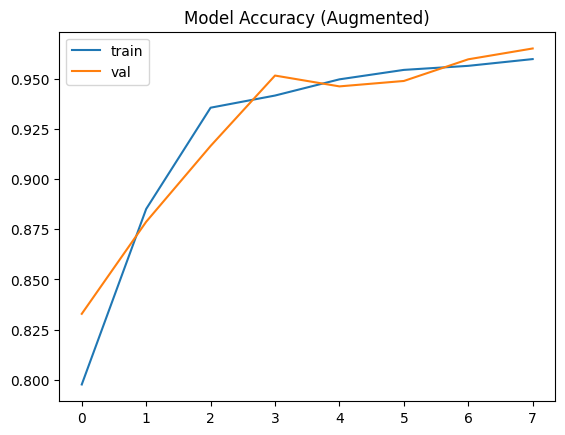

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model Accuracy (Augmented)")
plt.show()